<a href="https://colab.research.google.com/github/Viswa66/predictive-process-modeling/blob/main/SKLL_PBR_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import files

upload_dir = '/content/Data/'

# Create the directory if it doesn't exist
if not os.path.exists(upload_dir):
    os.makedirs(upload_dir)
    print(f"Created directory: {upload_dir}")
else:
    print(f"Directory already exists: {upload_dir}")

print("Please upload your CSV files now. After selecting, click 'Done' if prompted.")

uploaded = files.upload()

for filename, data in uploaded.items():
    with open(os.path.join(upload_dir, filename), 'wb') as f:
        f.write(data)
    print(f'Uploaded {filename} to {upload_dir}')

print("\nAll files uploaded to /content/Data/.")

Created directory: /content/Data/
Please upload your CSV files now. After selecting, click 'Done' if prompted.


Saving Thermophila_Master.csv to Thermophila_Master.csv
Saving Scenedesmus_Master.csv to Scenedesmus_Master.csv
Uploaded Thermophila_Master.csv to /content/Data/
Uploaded Scenedesmus_Master.csv to /content/Data/

All files uploaded to /content/Data/.


In [ ]:
import pandas as pd
import os
import glob

# 1. Define the directory (Colab's default upload folder)
folder_path = '/content/Data/'
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Lists to hold the individual dataframes before stitching
scenedesmus_logs = []
thermophila_logs = []

print(f"Found {len(all_files)} CSV files. Sorting by strain...")

# 2. Loop through every file and sort it based on the filename
for file in all_files:
    # Skip any previously created master files if you run this twice
    if 'Master' in file:
        continue

    try:
        # Read the CSV
        df = pd.read_csv(file)

        # Drop any empty/junk columns that often appear in raw exports
        df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

        # Sort into the correct bucket based on the filename
        if 'Scenedesmus' in file:
            scenedesmus_logs.append(df)
        elif 'Thermophila' in file:
            thermophila_logs.append(df)

    except Exception as e:
        print(f"Could not read {file}. Error: {e}")

# 3. Stitch, Clean, and Export the Scenedesmus Master Dataset
if scenedesmus_logs:
    print("\nStitching Scenedesmus data...")
    scen_master = pd.concat(scenedesmus_logs, ignore_index=True)

    # Optional: If you have a specific 'Date' or 'Time' column, uncomment the next two lines to ensure chronological order
    # scen_master['Date'] = pd.to_datetime(scen_master['Date'])
    # scen_master = scen_master.sort_values(by='Date')

    scen_master = scen_master.ffill().bfill() # Forward-fill missing sensor polls
    scen_master.to_csv('Scenedesmus_Master.csv', index=False)
    print(f"✅ Created Scenedesmus_Master.csv with {scen_master.shape[0]} rows and {scen_master.shape[1]} columns.")

# 4. Stitch, Clean, and Export the Thermophila Master Dataset
if thermophila_logs:
    print("\nStitching Thermophila data...")
    therm_master = pd.concat(thermophila_logs, ignore_index=True)

    # Optional: If you have a specific 'Date' or 'Time' column, uncomment the next two lines to ensure chronological order
    # therm_master['Date'] = pd.to_datetime(therm_master['Date'])
    # therm_master = therm_master.sort_values(by='Date')

    therm_master = therm_master.ffill().bfill() # Forward-fill missing sensor polls
    therm_master.to_csv('Thermophila_Master.csv', index=False)
    print(f"✅ Created Thermophila_Master.csv with {therm_master.shape[0]} rows and {therm_master.shape[1]} columns.")

print("\nPipeline complete. Master datasets are ready for analysis.")

Found 24 CSV files. Sorting by strain...

Stitching Scenedesmus data...
✅ Created Scenedesmus_Master.csv with 243035 rows and 16 columns.

Stitching Thermophila data...
✅ Created Thermophila_Master.csv with 163307 rows and 16 columns.

Pipeline complete. Master datasets are ready for analysis.


In [ ]:
from google.colab import files

print("Downloading Scenedesmus_Master.csv...")
files.download('Scenedesmus_Master.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

print("Downloading Thermophila_Master.csv...")
files.download('Thermophila_Master.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the pristine Digital Twins
scen_df = pd.read_csv('/content/Scenedesmus_Master.csv')
therm_df = pd.read_csv('/content/Thermophila_Master.csv')

# --- CONFIGURATION ---
# Change these to match your exact tubular CSV column names
time_col = 'Date' # Or 'Time', 'Timestamp'
metric_col = 'pH' # Using 'pH' as a suggested metric since 'Daily biomass growth (g/l/d)' was not found
# ---------------------

# DIAGNOSIS: Print column names to identify the correct metric column
print("Columns in Scenedesmus_Master.csv:")
print(scen_df.columns.tolist())
print("\nColumns in Thermophila_Master.csv:")
print(therm_df.columns.tolist())

# 2. Convert time columns to standard Datetime for plotting
scen_df[time_col] = pd.to_datetime(scen_df[time_col], errors='coerce')
therm_df[time_col] = pd.to_datetime(therm_df[time_col], errors='coerce')

# Drop any rows where the time parsing failed, and sort chronologically
scen_df = scen_df.dropna(subset=[time_col]).sort_values(by=time_col)
therm_df = therm_df.dropna(subset=[time_col]).sort_values(by=time_col)

# 3. Plot the Head-to-Head Benchmark
plt.figure(figsize=(14, 7))

# Plot Scenedesmus (Green for BG11)
plt.plot(scen_df[time_col], scen_df[metric_col],
         label='Scenedesmus (BG11)', color='#2ca02c', alpha=0.8, linewidth=2)

# Plot Thermophila (Orange/Red for P2)
plt.plot(therm_df[time_col], therm_df[metric_col],
         label='Thermophila (P2)', color='#d62728', alpha=0.8, linewidth=2)

# Formatting
plt.title(f'Strain Benchmarking: Scenedesmus vs. Thermophila - {metric_col}', fontsize=16, fontweight='bold')
plt.ylabel(metric_col, fontsize=12)
plt.xlabel('Timeline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()

plt.show()

In [ ]:
print(scen_df.columns.tolist())

['Date', 'Time', 'Main_Switch', 'Temperature_Outlet_SC', 'pH', 'Temperature_ambient', 'Pump', 'Pump_speed', 'Air_compressor', 'CO2_compressor', 'CO2_valve', 'CO2_vol_flow_in_valve', 'CO2_mass_flow_in_valve', 'CO2_Concentration_Hamilton', 'Temperature_CO2_Hamilton', 'l_N/min_set_value']


# Task
Fix the `FileNotFoundError` encountered during plotting and generate the head-to-head benchmark plot of Scenedesmus and Thermophila growth data from the uploaded CSV files in `/content/Data/`.

## Re-run Initial Data Upload (if necessary)

### Subtask:
Re-run the initial data upload cell to ensure all raw CSV files are uploaded to the `/content/Data/` directory. This step is only necessary if you want to upload new data or verify the presence of existing files.


### Instructions
Re-run the first code cell (cell_id: `6TD58QyIxfqk`) that contains the `files.upload()` command. Follow the prompts to select and upload your CSV files to the `/content/Data/` directory. After selecting, click 'Done' if prompted.

## Generate Master Datasets

### Subtask:
Generate the `Scenedesmus_Master.csv` and `Thermophila_Master.csv` files by processing the raw CSV data.


**Reasoning**:
The previous code cell failed because the master CSV files were not found. Re-running the code cell that generates these master files will ensure they are created in the correct directory.



In [ ]:
import pandas as pd
import os
import glob

# 1. Define the directory (Colab's default upload folder)
folder_path = '/content/Data/'
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Lists to hold the individual dataframes before stitching
scenedesmus_logs = []
thermophila_logs = []

print(f"Found {len(all_files)} CSV files. Sorting by strain...")

# 2. Loop through every file and sort it based on the filename
for file in all_files:
    # Skip any previously created master files if you run this twice
    if 'Master' in file:
        continue

    try:
        # Read the CSV
        df = pd.read_csv(file)

        # Drop any empty/junk columns that often appear in raw exports
        df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

        # Sort into the correct bucket based on the filename
        if 'Scenedesmus' in file:
            scenedesmus_logs.append(df)
        elif 'Thermophila' in file:
            thermophila_logs.append(df)

    except Exception as e:
        print(f"Could not read {file}. Error: {e}")

# 3. Stitch, Clean, and Export the Scenedesmus Master Dataset
if scenedesmus_logs:
    print("\nStitching Scenedesmus data...")
    scen_master = pd.concat(scenedesmus_logs, ignore_index=True)

    # Optional: If you have a specific 'Date' or 'Time' column, uncomment the next two lines to ensure chronological order
    # scen_master['Date'] = pd.to_datetime(scen_master['Date'])
    # scen_master = scen_master.sort_values(by='Date')

    scen_master = scen_master.ffill().bfill() # Forward-fill missing sensor polls
    scen_master.to_csv('Scenedesmus_Master.csv', index=False)
    print(f"✅ Created Scenedesmus_Master.csv with {scen_master.shape[0]} rows and {scen_master.shape[1]} columns.")

# 4. Stitch, Clean, and Export the Thermophila Master Dataset
if thermophila_logs:
    print("\nStitching Thermophila data...")
    therm_master = pd.concat(thermophila_logs, ignore_index=True)

    # Optional: If you have a specific 'Date' or 'Time' column, uncomment the next two lines to ensure chronological order
    # therm_master['Date'] = pd.to_datetime(therm_master['Date'])
    # therm_master = therm_master.sort_values(by='Date')

    therm_master = therm_master.ffill().bfill() # Forward-fill missing sensor polls
    therm_master.to_csv('Thermophila_Master.csv', index=False)
    print(f"✅ Created Thermophila_Master.csv with {therm_master.shape[0]} rows and {therm_master.shape[1]} columns.")

print("\nPipeline complete. Master datasets are ready for analysis.")

Found 2 CSV files. Sorting by strain...

Pipeline complete. Master datasets are ready for analysis.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import io
from google.colab import files

print("Please upload all 4 CSV files (The 2 Daily Logs and the 2 Dashboards):")
uploaded = files.upload()

# 1. Initialize empty variables for our dataframes
scen_log, scen_dash, therm_log, therm_dash = None, None, None, None

# 2. Smart-sort the uploaded files based on their filenames
for filename in uploaded.keys():
    name_lower = filename.lower()

    # Sort Thermophila files
    if 'thermophila' in name_lower:
        if 'log' in name_lower:
            therm_log = pd.read_csv(io.BytesIO(uploaded[filename]))
            print(f"Loaded: Thermophila Log -> {filename}")
        elif 'dashboard' in name_lower:
            therm_dash = pd.read_csv(io.BytesIO(uploaded[filename]))
            print(f"Loaded: Thermophila Dashboard -> {filename}")

    # Sort Scenedesmus (1KL HzB) files
    else:
        if 'log' in name_lower:
            scen_log = pd.read_csv(io.BytesIO(uploaded[filename]))
            print(f"Loaded: Scenedesmus Log -> {filename}")
        elif 'dashboard' in name_lower:
            scen_dash = pd.read_csv(io.BytesIO(uploaded[filename]))
            print(f"Loaded: Scenedesmus Dashboard -> {filename}")

# Ensure all files were uploaded successfully before proceeding
if any(df is None for df in [scen_log, scen_dash, therm_log, therm_dash]):
    raise ValueError("Missing one or more files. Please ensure you uploaded exactly 2 Logs and 2 Dashboards.")

# 3. Clean messy Excel headers (strip whitespace and newlines)
for df in [scen_log, scen_dash, therm_log, therm_dash]:
    df.columns = df.columns.str.strip().str.replace('\n', ' ')

# 4. Process and Merge Scenedesmus (BG11)
scen_log['Date'] = pd.to_datetime(scen_log['Date'], errors='coerce')
scen_dash['Date'] = pd.to_datetime(scen_dash['Date'], errors='coerce')

scen_merged = pd.merge(
    scen_log.dropna(subset=['Date']),
    scen_dash.dropna(subset=['Date']),
    on='Date',
    how='inner'
).sort_values('Date')

scen_merged['Run_Day'] = (scen_merged['Date'] - scen_merged['Date'].min()).dt.days

# 5. Process and Merge Thermophila (P2)
therm_log['Date'] = pd.to_datetime(therm_log['Date'], errors='coerce')
therm_dash['Date'] = pd.to_datetime(therm_dash['Date'], errors='coerce')

therm_merged = pd.merge(
    therm_log.dropna(subset=['Date']),
    therm_dash.dropna(subset=['Date']),
    on='Date',
    how='inner'
).sort_values('Date')

therm_merged['Run_Day'] = (therm_merged['Date'] - therm_merged['Date'].min()).dt.days

# 6. Isolate the Targets and ensure they are numeric
scen_target = 'Daily biomass growth (g/l/d)'
therm_target = 'Observed productivity (g/L/d)'

scen_merged[scen_target] = pd.to_numeric(scen_merged[scen_target], errors='coerce')
therm_merged[therm_target] = pd.to_numeric(therm_merged[therm_target], errors='coerce')

# 7. Plot the Head-to-Head Benchmark
plt.figure(figsize=(14, 7))

plt.plot(scen_merged['Run_Day'], scen_merged[scen_target],
         label='Scenedesmus (BG11)', color='#2ca02c', linewidth=2.5, marker='o', alpha=0.8)

plt.plot(therm_merged['Run_Day'], therm_merged[therm_target],
         label='Thermophila (P2)', color='#d62728', linewidth=2.5, marker='s', alpha=0.8)

# Formatting
plt.title('Full Systems Benchmark: Scenedesmus vs. Thermophila Productivity', fontsize=16, fontweight='bold')
plt.ylabel('Daily Productivity (g/L/d)', fontsize=12)
plt.xlabel('Days Since Reactor Inoculation', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

# 8. Save the Merged Master Datasets for Machine Learning
scen_merged.to_csv('Scenedesmus_Complete_ML_Dataset.csv', index=False)
therm_merged.to_csv('Thermophila_Complete_ML_Dataset.csv', index=False)
print("\n✅ Benchmark complete. Master datasets saved to your Colab workspace.")

Please upload all 4 CSV files (The 2 Daily Logs and the 2 Dashboards):


KeyboardInterrupt: 

Please upload your two raw Excel workbooks (.xlsx):


Saving 2nd_hzb_1KL_PBR_run_Thermophila.xlsx to 2nd_hzb_1KL_PBR_run_Thermophila (1).xlsx
Saving 1kl_Data_and_Variables_HzB.xlsx to 1kl_Data_and_Variables_HzB (1).xlsx
Recognized Thermophila Workbook: 2nd_hzb_1KL_PBR_run_Thermophila (1).xlsx
Recognized Scenedesmus Workbook: 1kl_Data_and_Variables_HzB (1).xlsx

Extracting and cleaning sheets natively...


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


Merging data into Digital Twins...


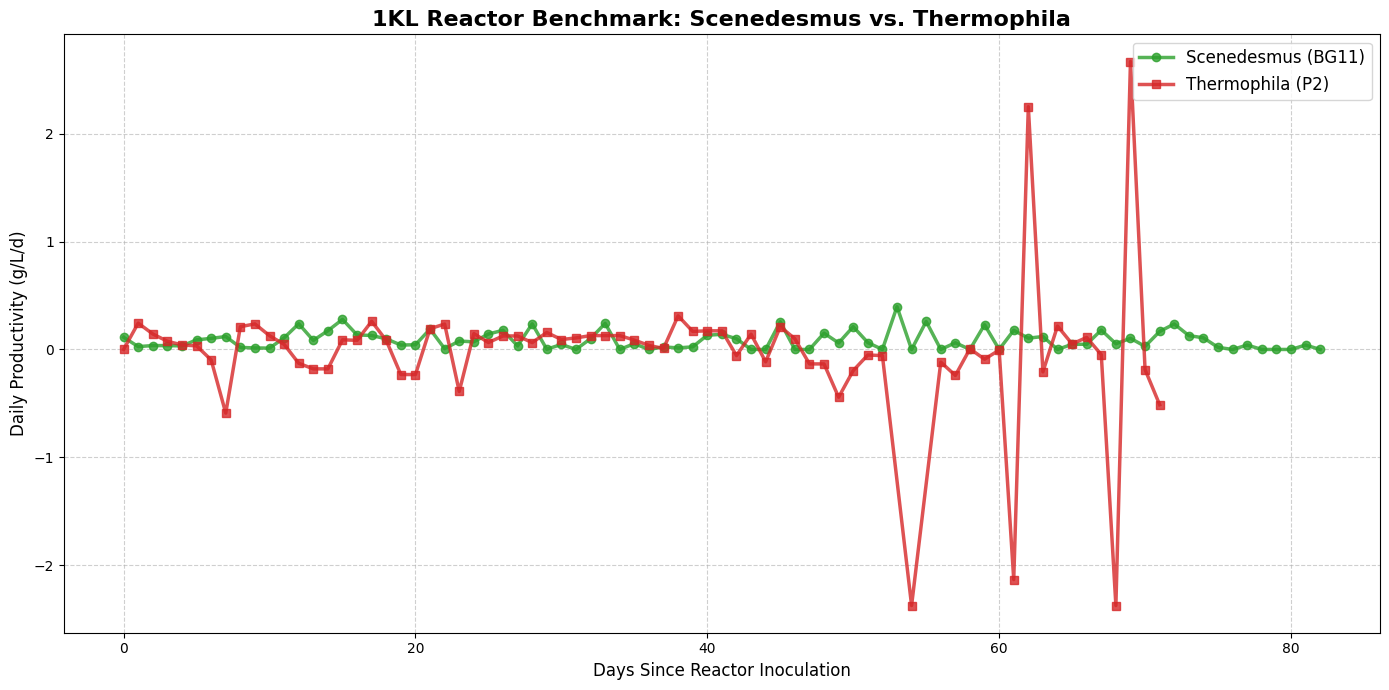

✅ Direct Excel processing complete. Master datasets saved.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import io
from google.colab import files

print("Please upload your two raw Excel workbooks (.xlsx):")
uploaded = files.upload()

# 1. Map the uploaded filenames dynamically
scen_excel = None
therm_excel = None

for filename in uploaded.keys():
    if 'Thermophila' in filename:
        therm_excel = io.BytesIO(uploaded[filename])
        print(f"Recognized Thermophila Workbook: {filename}")
    else:
        scen_excel = io.BytesIO(uploaded[filename])
        print(f"Recognized Scenedesmus Workbook: {filename}")

if not scen_excel or not therm_excel:
    raise ValueError("Missing an Excel workbook. Please ensure both are uploaded.")

# --- 2. Robust Excel Reader Function ---
def robust_excel_read(file_obj, sheet_name):
    """Hunts for the word 'Date' to dynamically bypass messy Excel title blocks."""
    file_obj.seek(0) # Reset file pointer

    # Read the top 20 rows without assuming a header
    temp_df = pd.read_excel(file_obj, sheet_name=sheet_name, nrows=20, header=None)
    header_idx = 0

    # Find the exact row that contains the word 'Date'
    for i, row in temp_df.iterrows():
        if any('date' == str(cell).strip().lower() for cell in row.values):
            header_idx = i
            break

    # Reload the sheet using the correct header row
    file_obj.seek(0)
    df = pd.read_excel(file_obj, sheet_name=sheet_name, skiprows=header_idx)

    # Force clean all column names (removes hidden spaces and newlines)
    df.columns = df.columns.astype(str).str.strip().str.replace('\n', ' ')

    # Ensure the Date column is properly capitalized and filter out junk rows
    for col in df.columns:
        if col.lower() == 'date':
            df.rename(columns={col: 'Date'}, inplace=True)
            break

    df = df.dropna(subset=['Date'])
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date']) # Drops any rows where 'Date' was just text/garbage

    return df

# --- 3. Extract the Sheets Safely ---
print("\nExtracting and cleaning sheets natively...")
scen_log = robust_excel_read(scen_excel, 'DAILY LOG')
scen_dash = robust_excel_read(scen_excel, 'DASHBOARD')

therm_log = robust_excel_read(therm_excel, 'Daily Log')
therm_dash = robust_excel_read(therm_excel, 'Dashboard')

# --- 4. Merge the Logs and Dashboards ---
print("Merging data into Digital Twins...")
scen_merged = pd.merge(scen_log, scen_dash, on='Date', how='inner').sort_values('Date')
therm_merged = pd.merge(therm_log, therm_dash, on='Date', how='inner').sort_values('Date')

# Normalize timeline to "Day 0" for a fair race
scen_merged['Run_Day'] = (scen_merged['Date'] - scen_merged['Date'].min()).dt.days
therm_merged['Run_Day'] = (therm_merged['Date'] - therm_merged['Date'].min()).dt.days

# --- 5. Clean Target Metrics for Plotting ---
scen_target = 'Daily biomass growth (g/l/d)'
therm_target = 'Observed productivity (g/L/d)'

scen_merged[scen_target] = pd.to_numeric(scen_merged[scen_target], errors='coerce')
therm_merged[therm_target] = pd.to_numeric(therm_merged[therm_target], errors='coerce')

# --- 6. Plot the Benchmark ---
plt.figure(figsize=(14, 7))

plot_scen = scen_merged.dropna(subset=[scen_target, 'Run_Day'])
plot_therm = therm_merged.dropna(subset=[therm_target, 'Run_Day'])

plt.plot(plot_scen['Run_Day'], plot_scen[scen_target],
         label='Scenedesmus (BG11)', color='#2ca02c', linewidth=2.5, marker='o', alpha=0.8)

plt.plot(plot_therm['Run_Day'], plot_therm[therm_target],
         label='Thermophila (P2)', color='#d62728', linewidth=2.5, marker='s', alpha=0.8)

plt.title('1KL Reactor Benchmark: Scenedesmus vs. Thermophila', fontsize=16, fontweight='bold')
plt.ylabel('Daily Productivity (g/L/d)', fontsize=12)
plt.xlabel('Days Since Reactor Inoculation', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

# --- 7. Export Master Datasets ---
scen_merged.to_csv('Scenedesmus_1KL_ML_Ready.csv', index=False)
therm_merged.to_csv('Thermophila_1KL_ML_Ready.csv', index=False)
print("✅ Direct Excel processing complete. Master datasets saved.")

In [ ]:
from google.colab import files

print("Downloading Scenedesmus_1KL_ML_Ready.csv...")
files.download('Scenedesmus_1KL_ML_Ready.csv')

print("Downloading Thermophila_1KL_ML_Ready.csv...")
files.download('Thermophila_1KL_ML_Ready.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

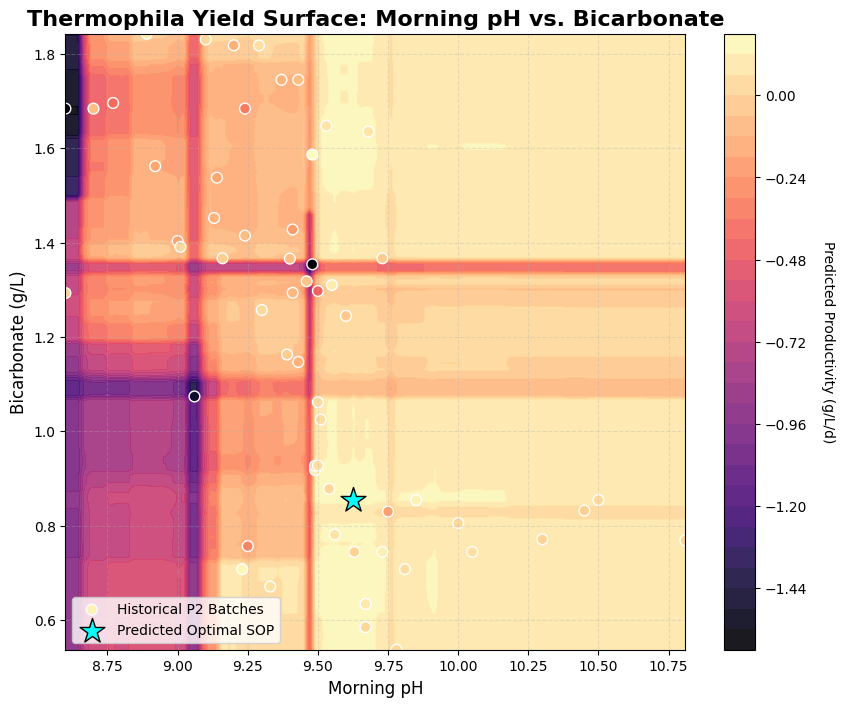

--- THERMOPHILA OPTIMAL SOP TARGETS ---
Target Morning pH: 9.63
Target Bicarbonate: 0.85 g/L
Predicted Maximum Productivity: 0.1591 g/L/d


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Load the winning Thermophila Master Dataset
df = pd.read_csv('Thermophila_1KL_ML_Ready.csv')

# 2. Define our control levers and our target KPI
target = 'Observed productivity (g/L/d)'

# We will use Morning pH and Bicarbonate as our primary kinetic drivers
features = ['Morning pH', 'Bicarbonate (g/L)']

# Clean the data for the machine learning model (Drop rows missing these specific sensors)
ml_df = df.dropna(subset=features + [target])

X = ml_df[features]
y = ml_df[target]

# 3. Train the Random Forest Digital Twin
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model.fit(X, y)

# 4. Simulate 10,000 virtual batches across all possible pH and Carbon combinations
ph_range = np.linspace(X['Morning pH'].min(), X['Morning pH'].max(), 100)
bic_range = np.linspace(X['Bicarbonate (g/L)'].min(), X['Bicarbonate (g/L)'].max(), 100)

xx, yy = np.meshgrid(ph_range, bic_range)
virtual_conditions = pd.DataFrame({
    'Morning pH': xx.ravel(),
    'Bicarbonate (g/L)': yy.ravel()
})

# Predict the yield for every coordinate
Z = model.predict(virtual_conditions).reshape(xx.shape)

# 5. Visualize the Predictive Response Surface
plt.figure(figsize=(10, 8))
contour = plt.contourf(xx, yy, Z, levels=30, cmap='magma', alpha=0.9)
cbar = plt.colorbar(contour)
cbar.set_label('Predicted Productivity (g/L/d)', rotation=270, labelpad=20)

# Overlay the historical Thermophila batches
plt.scatter(X['Morning pH'], X['Bicarbonate (g/L)'],
            c=y, cmap='magma', edgecolors='white', s=60, label='Historical P2 Batches')

# Pinpoint the absolute mathematical maximum
max_idx = np.unravel_index(np.argmax(Z, axis=None), Z.shape)
opt_ph = xx[max_idx]
opt_bic = yy[max_idx]
opt_yield = Z[max_idx]

plt.scatter(opt_ph, opt_bic, color='cyan', marker='*', s=350,
            edgecolor='black', label='Predicted Optimal SOP')

# Formatting
plt.title('Thermophila Yield Surface: Morning pH vs. Bicarbonate', fontsize=16, fontweight='bold')
plt.xlabel('Morning pH', fontsize=12)
plt.ylabel('Bicarbonate (g/L)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# 6. Print the exact instructions for the floor operators
print(f"--- THERMOPHILA OPTIMAL SOP TARGETS ---")
print(f"Target Morning pH: {opt_ph:.2f}")
print(f"Target Bicarbonate: {opt_bic:.2f} g/L")
print(f"Predicted Maximum Productivity: {opt_yield:.4f} g/L/d")